В работе используется плоский индекс FAISS с метрикой L2. Я пробовал использовать HNSW и менять метрики, но результат становился только хуже чем на этих настройках. Препроцессинг данных - TFIDF + SVD. Сжатие до 500 компонент почти не влияет на качество работы поиска

In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

import faiss
from faiss import normalize_L2
import time

In [2]:
def clean_text(text):
    """
    Cleans text: converts to string, removes punctuation/spaces, keeps Cyrillic/digits.
    """
    if not isinstance(text, (str, int, float)):
        return ""
    text = str(text).lower()
    return re.sub(r'[^а-яёa-z0-9]', '', text)

In [3]:
def create_full_fingerprint(df):
    """
    Combines ALL columns into a single string for fuzzy vectorization.
    name, surname, fathername, gender, birthdate are the primary fuzzy fields.
    passport, inn are included, letting char n-grams capture common typo structures.
    """
    df_filled = df.fillna("", inplace=False)
    
    fingerprints = (
        df_filled['surname'].apply(clean_text) + ' ' + 
        df_filled['name'].apply(clean_text) + ' ' +
        df_filled['fathername'].apply(clean_text) + ' ' +
        df_filled['gender'].apply(clean_text) + ' ' +
        df_filled['birthdate'].apply(clean_text) + ' ' +
        df_filled['passport'].apply(clean_text) + ' ' +
        df_filled['inn'].apply(clean_text)
    )
    return fingerprints.astype(str)

In [ ]:
def preprocess_and_vectorize(df1, df2, n_components=500):
    """
    Vectorizes and reduces dimensionality for FAISS indexing.
    """
    print("--- Stage 1: Preprocessing and Vectorization ---")
    
    df1_text = create_full_fingerprint(df1)
    df2_text = create_full_fingerprint(df2)
    
    all_text = pd.concat([df1_text, df2_text], ignore_index=True)

    print(f"Creating TF-IDF vectors (char n-gram 2,2)...")
    vectorizer = TfidfVectorizer(analyzer='char', 
                                 ngram_range=(2, 2), 
                                #  min_df=1, 
                                 max_features=100000)
    
    vectorizer.fit(all_text)
    X1_sparse = vectorizer.transform(df1_text).astype(np.float32)
    X2_sparse = vectorizer.transform(df2_text).astype(np.float32)
    
    print(f"Index size: {X1_sparse.shape[0]} entities x {X1_sparse.shape[1]} features (sparse)")

    print(f"Reducing dimensions to {n_components} using Truncated SVD...")
    
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    X1_svd = svd.fit_transform(X1_sparse)
    X2_svd = svd.transform(X2_sparse)
    
    # normalizer = Normalizer(copy=False)
    # X1_dense = normalizer.fit_transform(X1_svd)
    # X2_dense = normalizer.transform(X2_svd)

    # print(f"Final Index size: {X1_dense.shape} (dense, ready for FAISS GPU)")

    return X1_svd, X2_svd, df1, df2

In [5]:
df1 = pd.read_parquet('employees.parquet')
df2 = pd.read_parquet('orcs.parquet')

In [6]:
X1_dense, X2_dense, df1, df2 = preprocess_and_vectorize(df1, df2) 

--- Stage 1: Preprocessing and Vectorization ---
Creating TF-IDF vectors (char n-gram 2,2)...
Index size: 2011759 entities x 1378 features (sparse)
Reducing dimensions to 500 using Truncated SVD...


In [ ]:
def faiss_search(X1_dense, X2_dense, K=10):
    faiss.omp_set_num_threads(15)
    """
    Builds a FAISS Index on the GPU and performs the search.
    """
    D = X1_dense.shape[1]
    
    # res = faiss.StandardGpuResources()  

    index_flat = faiss.IndexFlatL2(D)
    # index_flat = faiss.index_cpu_to_gpu(res, 0, index_flat)

    index_flat.add(X1_dense) 

    print(f"Searching {X2_dense.shape[0]} queries for top {K} matches...")
    t0 = time.time()
    Distances, Indices = index_flat.search(X2_dense, K) 
    t1 = time.time()
    print(f"Search completed in {t1 - t0:.2f} seconds.")
    
    return Distances, Indices

In [10]:
D, I = faiss_search(X1_dense, X2_dense, K=10)

Searching 47633 queries for top 10 matches...
Search completed in 737.24 seconds.


In [11]:
import matplotlib.pyplot as plt

(array([0.15779343, 0.00415246, 0.        , 0.00830492, 0.00830492,
        0.01245737, 0.03321967, 0.02491476, 0.03737213, 0.04152459,
        0.07474427, 0.06228684, 0.07059181, 0.08720164, 0.07474427,
        0.08720164, 0.07889672, 0.07059181, 0.0913541 , 0.07889672,
        0.0913541 , 0.13287869, 0.1121164 , 0.12872605, 0.15779368,
        0.10796378, 0.14948875, 0.19931775, 0.1910134 , 0.2034702 ,
        0.17855601, 0.15364076, 0.23668982, 0.26160531, 0.265757  ,
        0.22838559, 0.23668982, 0.2989775 , 0.28651926, 0.35711202,
        0.36541587, 0.33219722, 0.33219625, 0.26575778, 0.35295851,
        0.39863667, 0.34880606, 0.36126342, 0.30312997, 0.35295955,
        0.40278676, 0.36956941, 0.41524653, 0.48999091, 0.41939652,
        0.43185639, 0.43185639, 0.419399  , 0.49414046, 0.42770393,
        0.53566802, 0.42355146, 0.41939652, 0.55227789, 0.51905816,
        0.48168314, 0.45261872, 0.56058282, 0.48999091, 0.56057951,
        0.56473528, 0.54397296, 0.54812542, 0.50

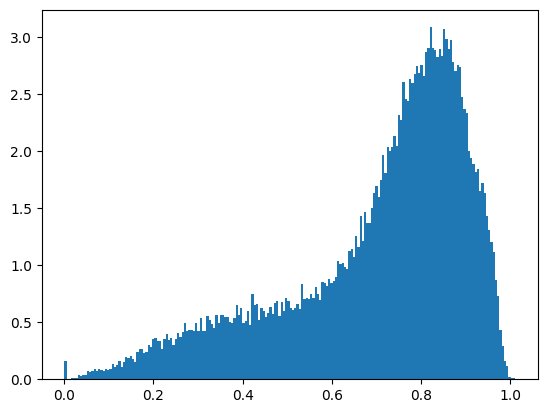

In [12]:
plt.hist(D[:, 0], density=True, bins=200)

In [ ]:
def enrich(df, orcs):
    df.fillna('', inplace=True)
    orcs.fillna('', inplace=True)
    suspects = df[(df['passport'].isin(orcs['passport']) | df['inn'].isin(orcs['inn'])) & (df['passport'] != '') & (df['inn'] != '')]
    table = [(id1, orcs.loc[orcs['passport'] == suspects.loc[id1, 'passport']].index) for id1 in suspects.index]
    table = [row for row in table if len(row[1])]
    table = [(id1, id2[0]) for id1, id2 in table]
    
    import numpy as np
    
    table = np.array(table)
    
    return table[:, 0]

In [14]:
I2 = enrich(df1, df2)

In [26]:
threshold = 0.6

In [47]:
idx = D[:, 0] <= threshold

In [48]:
I1 = I[idx, 0]

In [49]:
I1

array([1314497,  802441,  408549, ...,  162449, 1589036,  555520],
      shape=(11898,))

In [50]:
idxs = np.concat([I1, I2])

In [51]:
idxs = np.unique(idxs)

In [52]:
idxs.shape

(11744,)

In [53]:
res = pd.DataFrame({
    'orig_index': idxs
}).reset_index(names='id')

In [54]:
res

,id,orig_index
0,0,515
1,1,583
2,2,588
3,3,677
4,4,1012
...,...,...
11739,11739,2010990
11740,11740,2011285
11741,11741,2011352
11742,11742,2011423


In [55]:
res.to_csv('sub1.csv', index=False)

In [56]:
!cat sub1.csv

id,orig_index
0,515
1,583
2,588
3,677
4,1012
5,1478
6,1589
7,2098
8,2161
9,2250
10,2291
11,2479
12,2551
13,2664
14,3025
15,3409
16,3462
17,3598
18,3780
19,3823
20,4225
21,4263
22,4334
23,4438
24,4621
25,4729
26,4732
27,4985
28,4986
29,5007
30,5046
31,5511
32,5663
33,5704
34,5867
35,6197
36,6209
37,6210
38,6883
39,6898
40,7151
41,7277
42,7692
43,7787
44,8122
45,8218
46,8252
47,8533
48,8607
49,8977
50,9678
51,9681
52,9731
53,9931
54,9995
55,10088
56,10112
57,10365
58,10479
59,10532
60,10835
61,10858
62,11142
63,11323
64,11384
65,12723
66,12911
67,13219
68,13324
69,13367
70,13448
71,13513
72,13723
73,13943
74,14296
75,14363
76,14394
77,14438
78,14554
79,14565
80,14655
81,14779
82,15394
83,15536
84,15619
85,15689
86,15786
87,15798
88,16079
89,16182
90,16209
91,16253
92,16284
93,16560
94,17122
95,17380
96,18108
97,18318
98,18508
99,18613
100,18800
101,18995
102,19076
103,19261
104,20154
105,20222
106,20262
107,20283
108,20721
109,20753
110,20794
111,20919
112,20962
113,21214
114,21243
115,2